In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from power_systems_ops.read import login, read_tables, navigate

In [3]:
driver = login("coned@colorado.edu", "2025NYTeam")

In [74]:
tables = read_tables(driver)

Power plant portfolio
Electricity generation and fuel consumption in the past round
Electricity production per plant
Power plant availability
Overview of power plants
Fuel characteristics
Coal
Biomass
Natural gas
Nuclear fuel
Wind availability
Solar
Electricity demand
Invest in a new power plant
Dismantle power plants
Offer a plant for sale
Plants currently offered for sale
Accept offered plant
Sold plants
Power exchange results
Your off-peak hour electricity bids
Your shoulder hour electricity bids
Your peak hour electricity bids
All off-peak hour electricity bids
All shoulder hour electricity bids
All peak hour electricity bids
Electricity demand function


In [75]:
tables['clearing_prices']

,round,offpeak_demand,offpeak_price,shoulder_demand,shoulder_price,peak_demand,peak_price
0,5,9227.05,25.00,11263.07,32.00,13239.08,45.00
1,4,9203.66,25.75,11227.64,33.60,13199.12,46.70
2,3,9061.69,19.87,11032.26,28.60,13011.12,36.50
3,2,8719.92,42.68,10569.30,61.00,10940.05,227.19
4,1,8738.00,26.20,10695.80,30.42,12530.00,47.00


In [218]:
# Calculation inputs
plant_name = 'e7'
calc_round = 5   # Used for prices
capacity_factor_by_period = [0, 0, 1]

In [219]:
price_table = tables['clearing_prices'].set_index("round")
price_table

,offpeak_demand,offpeak_price,shoulder_demand,shoulder_price,peak_demand,peak_price
round,,,,,,
5,9227.05,25.00,11263.07,32.00,13239.08,45.00
4,9203.66,25.75,11227.64,33.60,13199.12,46.70
3,9061.69,19.87,11032.26,28.60,13011.12,36.50
2,8719.92,42.68,10569.30,61.00,10940.05,227.19
1,8738.00,26.20,10695.80,30.42,12530.00,47.00


In [220]:
periods = ['offpeak', 'shoulder', 'peak']
column_names = [f'{period}_price' for period in periods]
prices = [price_table.loc[calc_round][k] for k in column_names]

In [221]:
print(prices)

[np.float64(25.0), np.float64(32.0), np.float64(45.0)]


In [222]:
volume_by_period = [5000, 3600, 160]

In [223]:
d = tables['dispatch']
d

,type,cap,rel,eff,loan,payments,fixed,status,first_round,priority
Name,,,,,,,,,,
e9,solar,20.0,90.3,0.00,1.4,6,0.4,available,-3,1
inv-solar-3,solar,700.0,94.2,0.00,40.6,12,14.0,available,3,2
e4,wind,150.0,94.4,NaN,30.7,8,7.1,available,-1,3
e3,wind,50.0,94.7,NaN,9.9,9,2.4,available,0,4
e1,nuclear,800.0,91.9,33.53,308.1,5,92.5,available,-9,5
e2,powderCoal,700.0,94.8,40.19,65.5,14,85.6,available,0,6
e10,biomass,90.0,95.2,40.59,8.8,16,11.8,available,2,7
e6,naturalgasCCGT,600.0,92.9,53.99,38.5,3,39.5,available,-6,8
e8,naturalgasOCGT,50.0,93.3,37.40,3.2,0,1.3,available,-5,9


In [224]:
invest_table = tables['invest'].set_index("Type")

In [225]:
current = tables['dispatch'].loc[plant_name]
projected = invest_table.loc[current['type']]

In [226]:
cap = current['cap']
reliability = current['rel'] / 100
loan = current['loan']
loan_payments = current['payments']
fixed = current['fixed']
life_exp = projected['life_exp']

In [227]:
# Expected revenue (assuming constant reliability...) in Million Euros
exp_rev_by_period = [cap * price * volume * reliability * cap_factor / 1e6
                     for price, volume, cap_factor in zip(
                         prices, volume_by_period, capacity_factor_by_period)]
exp_rev = sum(exp_rev_by_period)

In [228]:
# Peaker plant retirement, assuming 100% reliability and 100% capacity factor at peak
# and 0% at lower load, what price do we need to break even?
i_peak = periods.index('peak')
# unit check: (M euro/year) * (1/MW) * (1 / hr) * (1e6Euro / 1M euro)
breakeven_price = fixed / (cap * volume_by_period[i_peak]) * 1e6
print(breakeven_price)

175.0


In [229]:
cap * volume / 1e6

NameError: name 'volume' is not defined

In [193]:
print(exp_rev_by_period)
print('total:', exp_rev)

[np.float64(0.0), np.float64(0.0), np.float64(0.3258)]
total: 0.3258


In [194]:
first_round = current['first_round']
current_round = 6
age = current_round - first_round
remaining_life = life_exp - age

In [195]:
expenditures = [ loan + fixed ] * loan_payments + [fixed] * (remaining_life - loan_payments)
expenditures = np.array(expenditures)

In [196]:
rev_over_time = [exp_rev] * remaining_life
rev_over_time = np.array(rev_over_time)

In [197]:
# initial_cost = 400
# expenditures[0] += initial_cost

In [198]:
cash_flow = np.cumsum(rev_over_time - expenditures)

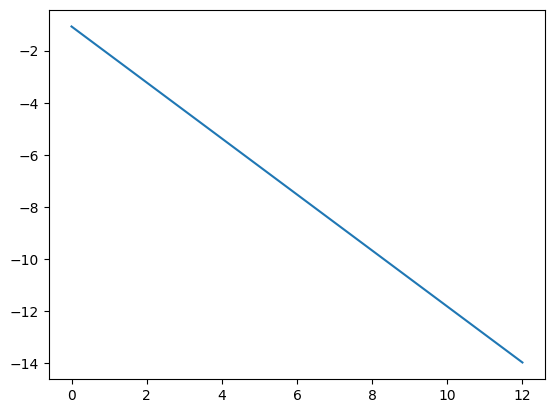

In [199]:
plt.plot(cash_flow)

In [ ]:
cash_flow = 

In [128]:
exp_rev * remaining_life

np.float64(6366.0968)

In [126]:
sum(expenditures)

np.float64(4778.0)

In [125]:
import matplotlib.pyplot as plt

In [124]:
print(expenditures)

[np.float64(400.6), np.float64(400.6), np.float64(400.6), np.float64(400.6), np.float64(400.6), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5), np.float64(92.5)]


In [93]:
cap

np.float64(800.0)

In [ ]:
yearly_exp = 

In [80]:
tables['dispatch'].loc[tab

,type,cap,rel,eff,loan,payments,fixed,status,first_round,priority
Name,,,,,,,,,,
e9,solar,20.0,90.3,0.00,1.4,6,0.4,available,-3,1
inv-solar-3,solar,700.0,94.2,0.00,40.6,12,14.0,available,3,2
e4,wind,150.0,94.4,NaN,30.7,8,7.1,available,-1,3
e3,wind,50.0,94.7,NaN,9.9,9,2.4,available,0,4
e1,nuclear,800.0,91.9,33.53,308.1,5,92.5,available,-9,5
e2,powderCoal,700.0,94.8,40.19,65.5,14,85.6,available,0,6
e10,biomass,90.0,95.2,40.59,8.8,16,11.8,available,2,7
e6,naturalgasCCGT,600.0,92.9,53.99,38.5,3,39.5,available,-6,8
e8,naturalgasOCGT,50.0,93.3,37.40,3.2,0,1.3,available,-5,9


In [62]:
prices.loc[5]

offpeak_demand      9227.05
offpeak_price         25.00
shoulder_demand    11263.07
shoulder_price        32.00
peak_demand        13239.08
peak_price            45.00
Name: 5, dtype: float64

In [10]:
from selenium.webdriver.common.by import By

In [12]:
ts = driver.find_elements(By.XPATH, "//div[@class='component table left white']")

In [15]:
for t in ts[:1]:
    print(t.find_element(By.TAG_NAME, 'h4').text)

Power exchange results


In [17]:
table_header = ts[0].find_element(By.TAG_NAME, 'thead')

In [27]:
hs = table_header.find_element(By.TAG_NAME, 'tr').find_elements(By.TAG_NAME, 'th')

In [28]:
for h in hs:
    print(h.get_attribute("colspan"))

None
2
2
2


In [23]:
h.text

'Period'

In [6]:
tables.keys()

dict_keys(['dispatch', 'last_generation', 'overview', 'fuels', 'coal', 'biomass', 'naturalgas', 'nuclear', 'wind', 'solar', 'demand', 'invest', 'Dismantle power plants', 'Offer a plant for sale', 'Plants currently offered for sale', 'Accept offered plant'])

In [7]:
tables['dispatch']

,type,cap,rel,eff,loan,payments,fixed,status,first_round,priority
Name,,,,,,,,,,
e9,solar,20.0,90.3,0.00,1.4,6,0.4,available,-3,1
inv-solar-3,solar,700.0,94.2,0.00,40.6,12,14.0,available,3,2
e4,wind,150.0,94.4,NaN,30.7,8,7.1,available,-1,3
e3,wind,50.0,94.7,NaN,9.9,9,2.4,available,0,4
e1,nuclear,800.0,91.9,33.53,308.1,5,92.5,available,-9,5
e2,powderCoal,700.0,94.8,40.19,65.5,14,85.6,available,0,6
e10,biomass,90.0,95.2,40.59,8.8,16,11.8,available,2,7
e6,naturalgasCCGT,600.0,92.9,53.99,38.5,3,39.5,available,-6,8
e8,naturalgasOCGT,50.0,93.3,37.40,3.2,0,1.3,available,-5,9


In [8]:
driver.quit()

In [ ]:
tables['

In [ ]:
tables